#Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

#Load Dataset

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/isvihanaluckytaa/itspiw/refs/heads/main/Country-data.csv')

df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

#Visualisasi Persebaran Data

Text(0, 0.5, 'inflation')

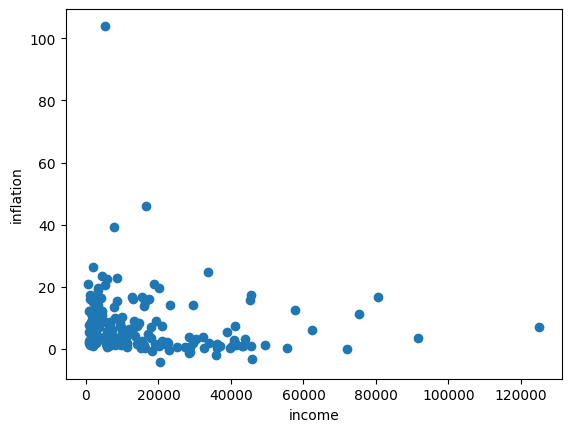

In [ ]:
plt.scatter(df['income'], df['inflation'])
plt.xlabel('income')
plt.ylabel('inflation')

#Data Scaling

In [ ]:
df = df[['income','inflation']]

In [ ]:
scaler = StandardScaler()
scaler.fit(df)
df_scaled = scaler.transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=['income','inflation'])

df_scaled

,income,inflation
0,-0.808245,0.157336
1,-0.375369,-0.312347
2,-0.220844,0.789274
3,-0.585043,1.387054
4,0.101732,-0.601749
...,...,...
162,-0.738527,-0.489784
163,-0.033542,3.616865
164,-0.658404,0.409732
165,-0.658924,1.500916


#Clustering menggunakan K-Means Algorithm

In [ ]:
cluster = KMeans(n_clusters=3)
cluster

y_predicted = cluster.fit_predict(df_scaled[['income','inflation']])
y_predicted

df['tipePenghasilan'] = y_predicted

df

<ipython-input-12-a46e8e18dc2e>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tipePenghasilan'] = y_predicted


,income,inflation,tipePenghasilan
0,1610,9.44,1
1,9930,4.49,1
2,12900,16.10,1
3,5900,22.40,1
4,19100,1.44,1
...,...,...,...
162,2950,2.62,1
163,16500,45.90,1
164,4490,12.10,1
165,4480,23.60,1


#Visualisasi Clustered Data

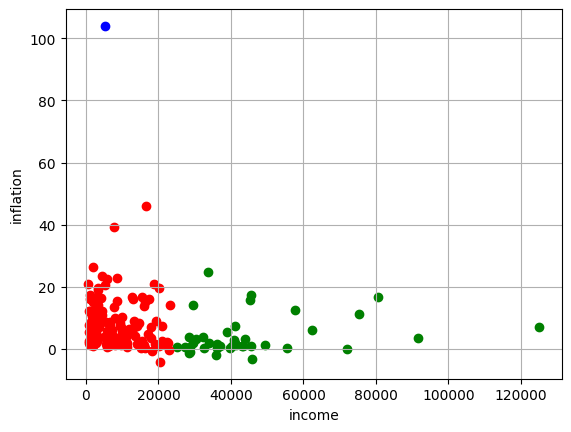

In [ ]:
df1 = df[df.tipePenghasilan==0]
df2 = df[df.tipePenghasilan==1]
df3 = df[df.tipePenghasilan==2]

plt.scatter(df1['income'],df1['inflation'],color='green')
plt.scatter(df2['income'],df2['inflation'],color='red')
plt.scatter(df3['income'],df3['inflation'],color='blue')

plt.xlabel('income')
plt.ylabel('inflation')
plt.grid()